# Heart Disease Prediction

## Dataset Overview
This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.


### Attribute Information:
* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved\
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 0 = normal; 1 = fixed defect; 2 = reversable defect

The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import(accuracy_score, precision_score,recall_score,
                            f1_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [2]:
data = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Shape of data
data.shape

(1025, 14)

In [4]:
# Data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## Exploratory Data Analysis (EDA)

In [5]:
# description of dataset
print("Data Statistics:")
data.describe().T

Data Statistics:


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


From the statistic report , the middle aged(29) to the elderly age(79) are the most affecyed. Men have dominated with 69% and 31% being female.Most pple have low chest pain.Many participant have a boderline high blood pressure.High average cholestral linked to heart disease risk.Only a small portion have high fasting sugar (diabetic risk)fbs. Wide range, values <100 bpm often indicate heart disease risk(thalach).Only 33% experience angina during exercise.High oldpeak indicates more severe heart issues.51% have heart disease, 49% don’t

#### check for missing values

In [6]:
print("Missing values:")
data.isnull().sum()

Missing values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

#### Check for duplicates and remove them

In [7]:
print("Duplicate:")
data.duplicated().sum()

Duplicate:


np.int64(723)

In [8]:
data= data.drop_duplicates().reset_index(drop=True)


In [9]:
# shape of data after removing duplicates
data.shape

(302, 14)

## DATA VISUALIZATION

#### Numerical Features

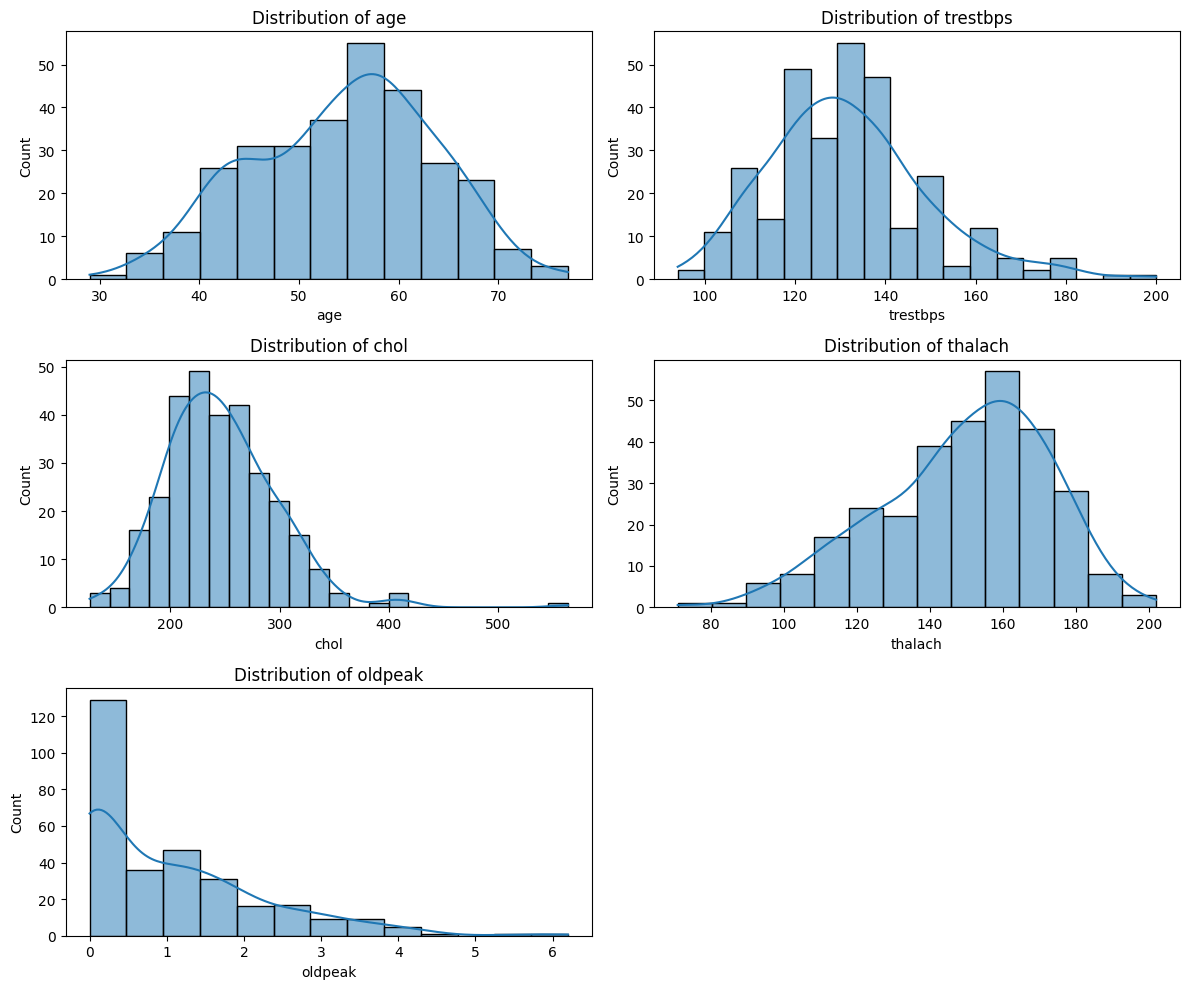

In [10]:
num_cols = ["age","trestbps","chol","thalach", "oldpeak"]

plt.figure(figsize=(12,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

#### Target distribution

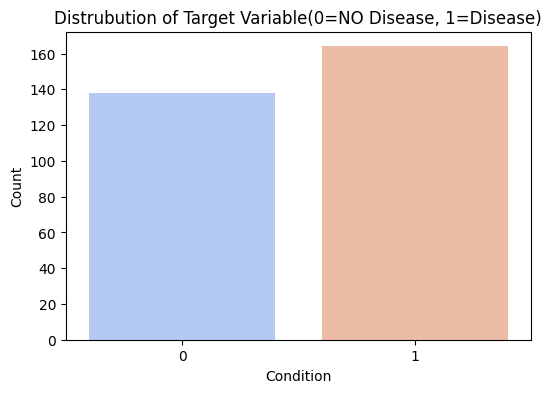

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='target',data=data, palette='coolwarm')
plt.title("Distrubution of Target Variable(0=NO Disease, 1=Disease)")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

The blue colour rep no heart disease and the red rep heart disease.The proportion indicates no imbalance.

#### AGE DISTRIBUTION BY HEART DISEASE STATUS

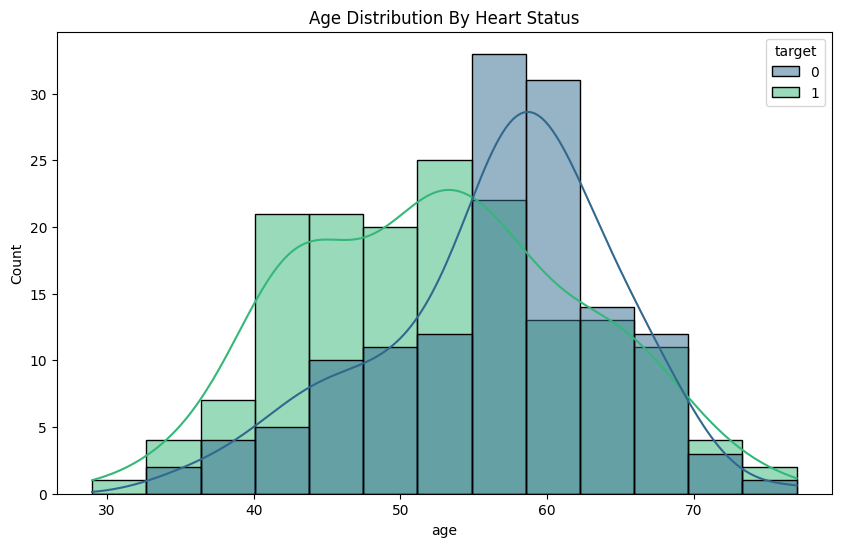

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(x='age', data=data,hue = 'target', kde = True, palette = 'viridis' )
plt.title("Age Distribution By Heart Status")
plt.show()

#### FEATURE CORRELATION MATRIX

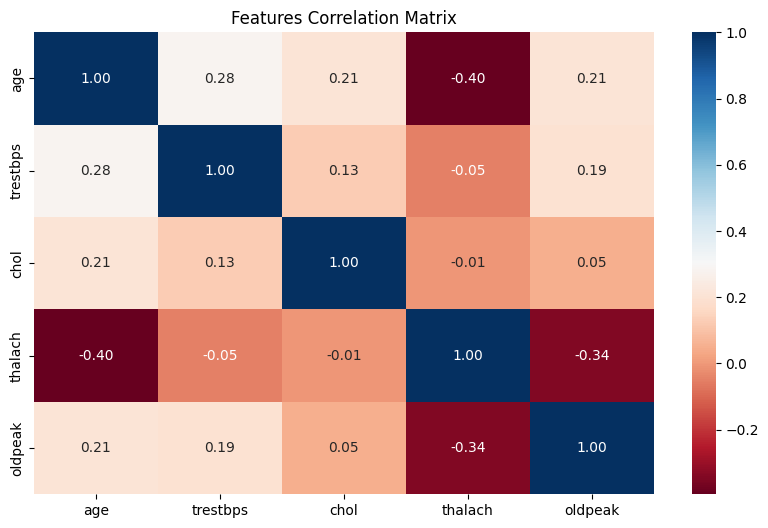

In [13]:
selected = data[num_cols]
corr_matrix = selected.corr()
plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap='RdBu',fmt= '.2f')
plt.title("Features Correlation Matrix")
plt.show()

when we compare age and thalach(heartrate) has a srong negative ,when increase in age heart rate tend to decrease and vice verser

In [14]:
target_counts = data['target'].value_counts()
target_percent = data['target'].value_counts(normalize=True) * 100

print("Target Counts:\n", target_counts)
print("\nTarget Percentage:\n", target_percent.round(2))

Target Counts:
 target
1    164
0    138
Name: count, dtype: int64

Target Percentage:
 target
1    54.3
0    45.7
Name: proportion, dtype: float64


In [15]:
# Target distribution
print("\nTarget Distribution:")
print(data['target'].value_counts())
print(f"Class Balance: {data['target'].value_counts(normalize=True).to_dict()}")


Target Distribution:
target
1    164
0    138
Name: count, dtype: int64
Class Balance: {1: 0.543046357615894, 0: 0.45695364238410596}


#### REMOVE OUTLIERS

In [16]:
# remove outliers using IQR method
outlier_cols=['chol', 'trestbps', 'oldpeak','thalach']

for col in outlier_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((data[col] < lower) | (data[col]> upper)).sum()
        print(f"{col:12} - Outliers: {outliers:3} | Range: [{lower:.1f}, {upper:.1f}]")
        data = data[(data[col] >= lower) & (data[col] <= upper)]
print(f"\n Dataset shape after removal outiers: {data.shape}")

chol         - Outliers:   5 | Range: [115.4, 370.4]
trestbps     - Outliers:   9 | Range: [90.0, 170.0]
oldpeak      - Outliers:   4 | Range: [-2.4, 4.0]
thalach      - Outliers:   1 | Range: [79.9, 220.9]

 Dataset shape after removal outiers: (283, 14)


## FEATURE ENGINEERING

In [17]:
# creating new features from existing one
data['age_thalach_ratio'] = data['age']/(data['thalach'] + 1)
data['chol_age_interaction'] = data ['chol']* data['age']
data['bp_chol_ratio'] = data['trestbps']/(data['chol'] + 1)

print("Created 3 nteraction features")


Created 3 nteraction features


#### ENCODING CATEGORY FEATURES

In [18]:
#Features to ONE HOT ENCODE(multi-class category)
categorical_cols  = ['cp', 'restecg', 'slope', 'ca', 'thal']

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Features expanded from 14 to {len(data.columns)}")

Features expanded from 14 to 26


## SPLIT DATA

In [19]:
X = data.drop('target', axis=1)
y = data['target']

X_train,X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]}")
print(f"Test set:     {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training set: 226
Test set:     57
Number of features: 25


#### FEATURE SCALING

In [20]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
                      'age_thalach_ratio', 'chol_age_interaction', 'bp_chol_ratio']

scaler = StandardScaler()
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])


print(f"Scaled feature statistics (train set):")
print(X_train[continuous_features].describe().loc[['mean', 'std']].round(3))

Scaled feature statistics (train set):
        age  trestbps   chol  thalach  oldpeak  age_thalach_ratio  \
mean -0.000    -0.000 -0.000    0.000   -0.000              0.000   
std   1.002     1.002  1.002    1.002    1.002              1.002   

      chol_age_interaction  bp_chol_ratio  
mean                 0.000          0.000  
std                  1.002          1.002  


## BASELINE MODEL

In [21]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_acc = baseline.score(X_test, y_test)

print(f"Baseline (Most Frequent Class): {baseline_acc:.4f}")
print("(Any model should beat this!)")

Baseline (Most Frequent Class): 0.5614
(Any model should beat this!)


## MODEL COMPARISON

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)

}

results = {}
print(f"\n{'Model':>20} {'Train Acc':>10} {'Test Acc':>10} {'CV Score':>10}")
print("_"* 52)

for name, model in models.items():
    #train
    model.fit(X_train, y_train)

    #Evaluate
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    #Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()

    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'cv_score': cv_mean
    }

    print(f"{name:<20} {train_acc:>10.4f} {test_acc:>10.4f} {cv_mean:>10.4f}")

#Identify best model
best_model_name = max(results, key=lambda x: results[x]['test_acc'])
best_model = results[best_model_name]['model']

print(f"\n Best Model: {best_model_name}")
print(f" Test Accuracy: {results[best_model_name]['test_acc']:.4f}")


               Model  Train Acc   Test Acc   CV Score
____________________________________________________
Logistic Regression      0.8850     0.8421     0.8317
Decision Tree            1.0000     0.8070     0.7654
Random Forest            1.0000     0.7719     0.7789
Gradient Boosting        1.0000     0.7544     0.7965
SVM                      0.8982     0.7895     0.8143
KNN                      0.8451     0.7719     0.7743

 Best Model: Logistic Regression
 Test Accuracy: 0.8421


#### HYPERPERAMETER TUNING THE BEST MODEL

In [23]:
param_grid = {
    'n_estimators': [100,200,300,400],
    'max_depth': [5,10,15,20, None],
    'min_samples_split':[2,5,10,15],
    'min_samples_leaf':[1,2,4,6],
    'max_features': ['sqrt','log2', None],
    'bootstrap':[True, False],
    'criterion':['gini', 'entropy']
}

print("Parameter grid:")
for param, values in param_grid.items():
    print(f" {param:20}: {values}")

print (f"\n Total combinations: {np.prod([len(v) for v in param_grid.values()])}")

#using random searchcv for fast tuning'''

from sklearn.model_selection import RandomizedSearchCV

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

print("running randomized seach")

random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)

print("Tuning Results")

print(f"\n Best Parameter Found:")

for param, value in random_search.best_params_.items():
    print(f" {param:20}: {value}")

print(f"\n Best Cross-Validation Score: {random_search.best_score_:.4f}")
print(f"\n Improvement over default: {random_search.best_score_ - results['Random Forest']['cv_score']:.4f}")

#get the best model
final_model = random_search.best_estimator_

#show top 5 parameter combinations
print("\nTop 5 Parameter Combinations:")
results_data = pd.DataFrame(random_search.cv_results_)
results_data = results_data.sort_values('rank_test_score')
print(results_data[['params', 'mean_test_score', 'std_test_score']].head())

#compare default vs tuned model
print("DEFAULT VS TUNED MODEL COMPARISON")

default_rf = RandomForestClassifier(random_state=42)
default_rf.fit(X_train, y_train)

print(f"\nDefault Random Forest:")
print(f" Training Accuracy: {default_rf.score(X_train, y_train):.4f}")
print(f" Test Accuracy: {default_rf.score(X_test, y_test):.4f}")
print(f" CV Score: {cross_val_score(default_rf, X_train, y_train, cv=5).mean():.4f}")

print(f"\n Tuned Random Forest:")
print(f" Training Accuracy: {final_model.score(X_train, y_train):4f}")
print(f" Test Accuracy:  {final_model.score(X_test, y_test):.4f}")
print(f" CV Score:   {random_search.best_score_:.4f}")

improvement = final_model.score(X_test, y_test) - default_rf.score(X_test, y_test)
print(f"\n Test Accuracy Improvement: {improvement:+.4f}")

if improvement > 0:
    print("Tuning Improved model")
else:
    print("Default parameter were already good.using tuned model")

Parameter grid:
 n_estimators        : [100, 200, 300, 400]
 max_depth           : [5, 10, 15, 20, None]
 min_samples_split   : [2, 5, 10, 15]
 min_samples_leaf    : [1, 2, 4, 6]
 max_features        : ['sqrt', 'log2', None]
 bootstrap           : [True, False]
 criterion           : ['gini', 'entropy']

 Total combinations: 3840
running randomized seach
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Tuning Results

 Best Parameter Found:
 n_estimators        : 400
 min_samples_split   : 15
 min_samples_leaf    : 4
 max_features        : log2
 max_depth           : 10
 criterion           : entropy
 bootstrap           : True

 Best Cross-Validation Score: 0.8099

 Improvement over default: 0.0309

Top 5 Parameter Combinations:
                                               params  mean_test_score  \
31  {'n_estimators': 400, 'min_samples_split': 15,...         0.809855   
10  {'n_estimators': 400, 'min_samples_split': 5, ...         0.801159   
29  {'n_estimators': 400,

## FINAL EVALUATION

In [24]:
#PREDICTION
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

#metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Set Performance:")
print(f" Accuracy:  {accuracy:.4f}")
print(f" Precision:  {precision:.4f}")
print(f" Recall:  {recall:.4f}")
print(f" F1-Score:  {f1:.4f}")
print(f" ROC-AUC:  {roc_auc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


Test Set Performance:
 Accuracy:  0.8070
 Precision:  0.8889
 Recall:  0.7500
 F1-Score:  0.8136
 ROC-AUC:  0.8725

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.73      0.88      0.80        25
     Disease       0.89      0.75      0.81        32

    accuracy                           0.81        57
   macro avg       0.81      0.81      0.81        57
weighted avg       0.82      0.81      0.81        57



## VISUALIZATION


 Visualizatiion saved as 'heart_disease_evaluation.png'


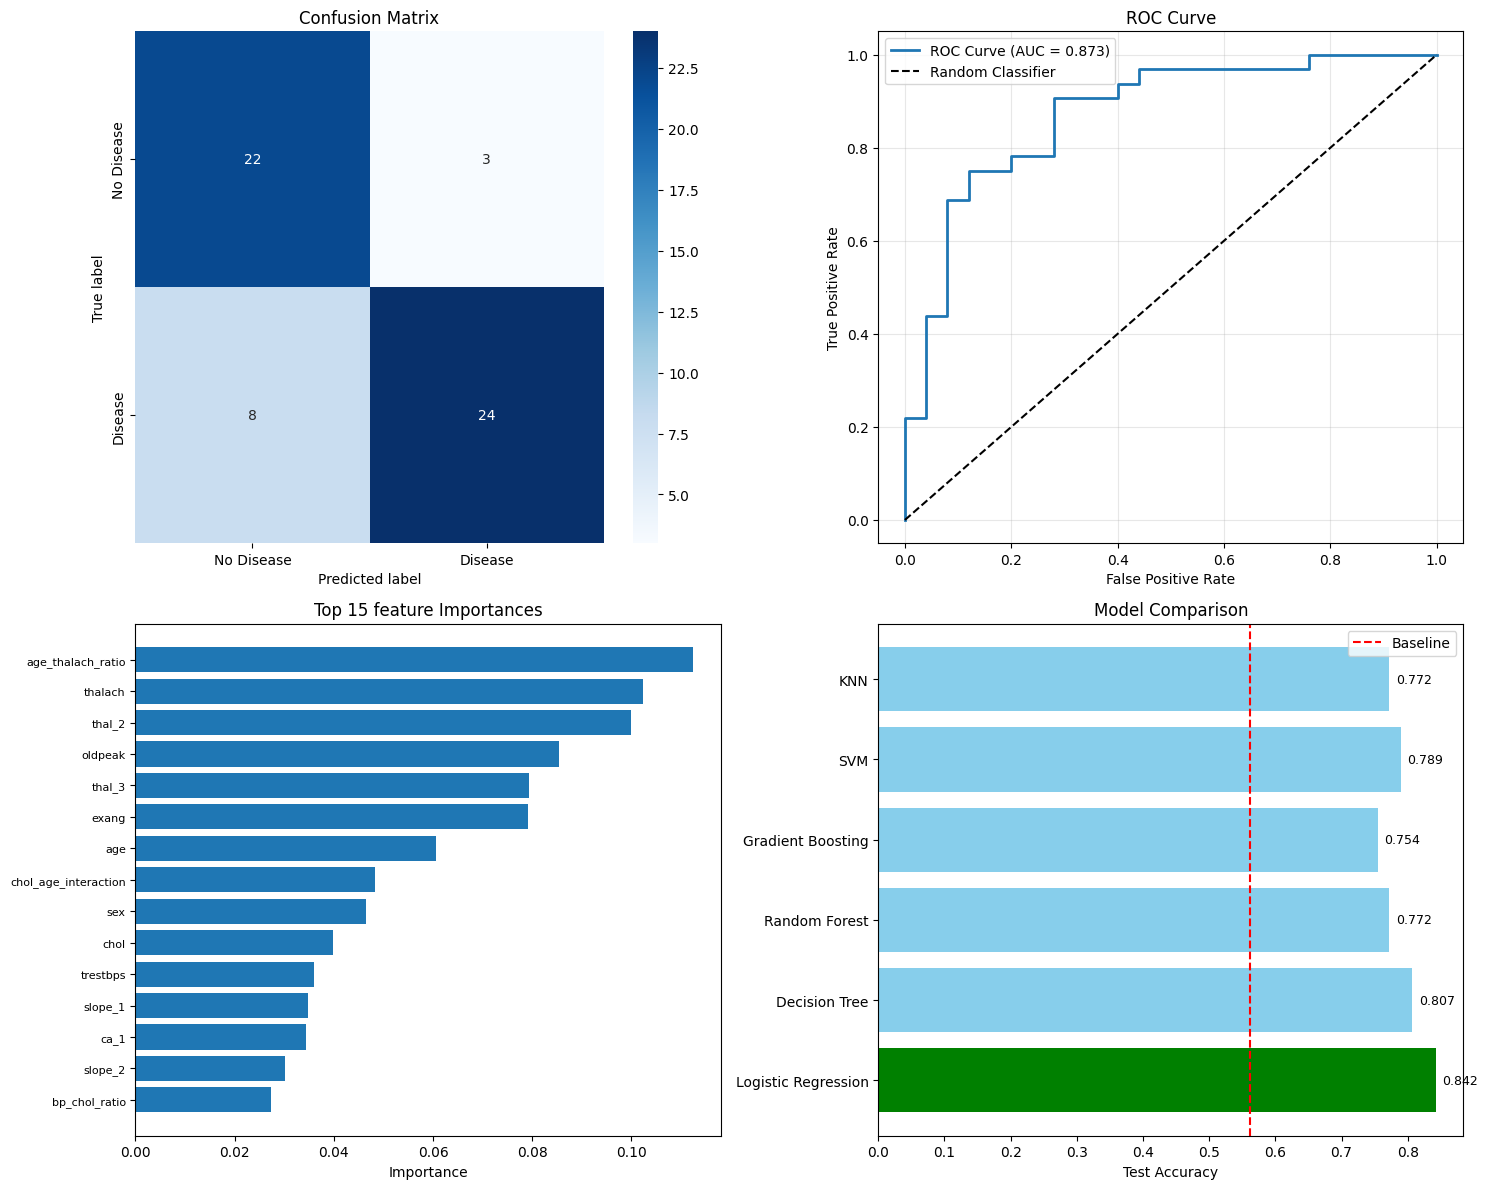

In [25]:
fig, axes =  plt.subplots(2, 2, figsize=(15, 12))

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
           xticklabels=['No Disease', 'Disease'],
           yticklabels=['No Disease', 'Disease'])
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_ylabel('True label')
axes[0, 0].set_xlabel('Predicted label')

#ROC CURVE
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
axes[0,1].plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
axes[0,1].plot([0,1], [0, 1], 'k--', label='Random Classifier')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
#features importance
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]

    axes[1, 0].barh(range(15), importances[indices])
    axes[1, 0].set_yticks(range(15))
    axes[1, 0].set_yticklabels(X_train.columns[indices], fontsize=8)
    axes[1, 0].set_xlabel("Importance")
    axes[1, 0].set_title('Top 15 feature Importances')
    axes[1, 0].invert_yaxis()

else:
    axes[1, 0].text(0.5,0,5, 'Feature importances\nnot available for this model',
                               ha='center', va='center', fontsize=12)
    axes[1, 0].axis('off')


#Model comparison
model_names = list(results.keys())
test_scores = [results[name]['test_acc'] for name in model_names]

colors = ['green' if name == best_model_name else 'skyblue' for name in model_names]
bars = axes[1, 1].barh(model_names, test_scores, color=colors)
axes[1, 1].set_xlabel('Test Accuracy')
axes[1, 1].set_title('Model Comparison')
axes[1, 1].axvline(x=baseline_acc, color='red', linestyle='--',label='Baseline')
axes[1, 1].legend()

#add value labels
for bar, score in zip(bars, test_scores):
    axes[1, 1].text(score + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('heart_disease_evaluation.png', dpi=300, bbox_inches='tight')
print("\n Visualizatiion saved as 'heart_disease_evaluation.png'")
plt.show()

## SAVE MODEL

In [26]:
import joblib
from sklearn.pipeline import Pipeline

# ─── BUILD THE PIPELINE ───────────────────────────────────────────────────────

heart_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', final_model)   
])


heart_pipeline.fit(X_train, y_train)


pipeline_acc = heart_pipeline.score(X_test, y_test)
print(f"Pipeline Test Accuracy: {pipeline_acc:.4f}")

# ─── SAVE EVERYTHING TO ONE FILE ─────────────────────────────────────────────
joblib.dump(heart_pipeline, 'heart_pipeline.pkl')
print("✅ Pipeline saved as: heart_pipeline.pkl")

# ─── QUICK VERIFICATION ───────────────────────────────────────────────────────
loaded_pipeline = joblib.load('heart_pipeline.pkl')

# Example: predict on the test set with the loaded pipeline
sample = X_test.iloc[:5]                          
predictions  = loaded_pipeline.predict(sample)
probabilities = loaded_pipeline.predict_proba(sample)[:, 1]

print("\nSample Predictions:", predictions)
print("Probabilities     :", probabilities.round(4))
print("\nPipeline steps stored:")
for name, step in loaded_pipeline.named_steps.items():
    print(f"  {name}: {step}")


Pipeline Test Accuracy: 0.8070
✅ Pipeline saved as: heart_pipeline.pkl

Sample Predictions: [0 1 1 1 0]
Probabilities     : [0.1695 0.609  0.9097 0.7439 0.0698]

Pipeline steps stored:
  scaler: StandardScaler()
  classifier: RandomForestClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       min_samples_leaf=4, min_samples_split=15,
                       n_estimators=400, n_jobs=-1, random_state=42)
